# Análisis exploratorio de datos: Tarjetas de crédito y débito

## 1. Presentación y procedencia del dataset

**Dataset:** Tarjetas de crédito y débito

**Fuente:** Datos Abiertos Colombia

**Entidad/fuente de procedencia:** Superintendencia Financiera de Colombia

**URL oficial del dataset:**  
https://www.datos.gov.co/Econom-a-y-Finanzas/Tarjetas-de-cr-dito-y-d-bito/h2jg-r3zg/about_data

**Archivo utilizado:** `Tarjetas_de_crédito_y_débito_20260928.csv`

**Fecha de acceso:** 28 de septiembre de 2026

**Propósito del análisis:**  
Realizar un análisis exploratorio de los datos relacionados con tarjetas de crédito y débito, identificando patrones, comportamientos, relaciones entre variables y diferencias entre los principales indicadores registrados en el dataset.

## 2. Preguntas de investigación

A partir de la estructura y características del dataset, se plantean las siguientes preguntas:

1. ¿Cómo ha evolucionado el número de tarjetas de crédito y débito a lo largo del tiempo?

2. ¿Cuál es el comportamiento de las tarjetas de crédito y débito vigentes, canceladas y bloqueadas temporalmente?

3. ¿Qué diferencias se presentan entre los valores asociados a personas naturales y personas jurídicas?

4. ¿Qué diferencias se observan entre las tarjetas de crédito y débito al comparar sus valores promedio, medianos y extremos?

5. ¿Qué relaciones pueden identificarse entre los principales indicadores mediante el análisis bivariado?

6. ¿Qué patrones se pueden identificar al comparar los indicadores entre entidades y periodos de tiempo?

## 3. Carga y exploración inicial de los datos

En esta sección se carga el conjunto de datos oficial de tarjetas de crédito y débito y se realiza una exploración inicial de su estructura, dimensiones, tipos de datos y contenido.

El objetivo es conocer las características generales del dataset antes de realizar el proceso de limpieza y transformación de los datos.

In [239]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [240]:
df = pd.read_csv("../datos/Tarjetas_de_crédito_y_débito_20260928.csv")

In [241]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 184400
Columnas: 11


### 3.1 Exploración inicial

Se realiza una exploración inicial del conjunto de datos para identificar su tamaño, número de variables, nombres de las columnas, tipos de datos y una muestra de los registros.

Esta revisión permite conocer la estructura original de los datos antes de iniciar el proceso de limpieza y transformación.

In [242]:
df.head()

,TIPOENTIDAD,CODIGOENTIDAD,NOMBREENTIDAD,FECHACORTE,COD_UCA,NOMBRE_UCA,SUBCUENTA,DESCRIPCION,PERSONA_NATURAL,PERSONA_JURIDICA,TOTAL_TARJETAS
0,1,1,BANCO DE BOGOTA S. A.,30/04/2016,1,CREDIBANCO-VISA,5,Número total de tarjetas de crédito vigentes ...,528.873,52.137,581.010
1,1,1,BANCO DE BOGOTA S. A.,31/01/2015,1,CREDIBANCO-VISA,5,Número total de tarjetas de crédito vigentes ...,477.104,53.898,531.002
2,1,1,BANCO DE BOGOTA S. A.,31/12/2024,1,CREDIBANCO-VISA,5,Número total de tarjetas de crédito vigentes ...,941.902,37.413,979.315
3,1,1,BANCO DE BOGOTA S. A.,30/09/2016,1,CREDIBANCO-VISA,5,Número total de tarjetas de crédito vigentes ...,529.628,51.739,581.367
4,1,1,BANCO DE BOGOTA S. A.,31/03/2022,1,CREDIBANCO-VISA,5,Número total de tarjetas de crédito vigentes ...,894.240,39.856,934.096


In [243]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 184400 entries, 0 to 184399
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   TIPOENTIDAD       184400 non-null  int64
 1   CODIGOENTIDAD     184400 non-null  int64
 2   NOMBREENTIDAD     184400 non-null  str  
 3   FECHACORTE        184400 non-null  str  
 4   COD_UCA           184400 non-null  int64
 5   NOMBRE_UCA        184400 non-null  str  
 6   SUBCUENTA         184400 non-null  int64
 7   DESCRIPCION       184400 non-null  str  
 8   PERSONA_NATURAL   184400 non-null  str  
 9   PERSONA_JURIDICA  184400 non-null  str  
 10  TOTAL_TARJETAS    184400 non-null  str  
dtypes: int64(4), str(7)
memory usage: 15.5 MB


In [244]:
df.isnull().sum()

TIPOENTIDAD         0
CODIGOENTIDAD       0
NOMBREENTIDAD       0
FECHACORTE          0
COD_UCA             0
NOMBRE_UCA          0
SUBCUENTA           0
DESCRIPCION         0
PERSONA_NATURAL     0
PERSONA_JURIDICA    0
TOTAL_TARJETAS      0
dtype: int64

In [245]:
df.duplicated().sum()

np.int64(0)

In [246]:
df["DESCRIPCION"].value_counts()

DESCRIPCION
Saldo de la cartera por tarjeta de crédito                                        6647
Número de  transacciones por avances a nivel nacional con tarjeta de crédito      6631
Monto de los intereses corrientes por compras y avances con tarjeta de crédito    6630
Monto de los intereses de mora por compras y avances  con tarjeta de crédito      6601
Total cupo de crédito no utilizado por todos los tarjetahabientes                 6507
                                                                                  ... 
Tarifa Interbancaria de Intercambio - TII por Tarjeta Débito Maestro               139
Tarifa Interbancaria de Intercambio - TII por Tarjeta Master Débito                 90
GASTOS POR TARIFA INTER.                                                            19
NUMERO TOTAL T. CON CHIP                                                            19
NUME TOTAL TA. TECNOLOGIA                                                           19
Name: count, Length: 66, dtype:

In [247]:
df["DESCRIPCION"].value_counts().head(15)

DESCRIPCION
Saldo de la cartera por tarjeta de crédito                                                 6647
Número de  transacciones por avances a nivel nacional con tarjeta de crédito               6631
Monto de los intereses corrientes por compras y avances con tarjeta de crédito             6630
Monto de los intereses de mora por compras y avances  con tarjeta de crédito               6601
Total cupo de crédito no utilizado por todos los tarjetahabientes                          6507
Número total de tarjetas de crédito vigentes  a la fecha de corte                          6502
Monto de las transacciones por compras con tarjeta de crédito a nivel nacional             6492
Número de transacciones por compras a nivel nacional con tarjeta de crédito                6491
Número total de tarjetas de crédito canceladas                                             6449
Número total de tarjetas de crédito vigentes durante el mes                                6292
Número total de tarjetas de 

In [248]:
df["FECHACORTE"].min(), df["FECHACORTE"].max()

('28/02/2015', '31/12/2025')

## 4. Limpieza y transformación de los datos

En esta etapa se realizan las transformaciones necesarias para preparar los datos para el análisis.

Se verifica la presencia de valores nulos y registros duplicados, se transforma la variable `FECHACORTE` al formato de fecha y se convierten las variables numéricas almacenadas como texto a un formato numérico.

La conversión de las variables numéricas requiere tener en cuenta el formato utilizado en el dataset, donde el punto (`.`) representa el separador de miles y la coma (`,`) representa el separador decimal.

In [249]:
df["FECHACORTE"] = pd.to_datetime(
    df["FECHACORTE"],
    format="%d/%m/%Y"
)

In [250]:
df["FECHACORTE"].dtype

dtype('<M8[us]')

In [251]:
columnas_numericas = [
    "PERSONA_NATURAL",
    "PERSONA_JURIDICA",
    "TOTAL_TARJETAS"
]

for columna in columnas_numericas:
    df[columna] = pd.to_numeric(
        df[columna]
        .astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False),
        errors="coerce"
    )

In [252]:
df[["PERSONA_NATURAL", "PERSONA_JURIDICA", "TOTAL_TARJETAS"]].dtypes

PERSONA_NATURAL     float64
PERSONA_JURIDICA    float64
TOTAL_TARJETAS      float64
dtype: object

In [253]:
df[["PERSONA_NATURAL", "PERSONA_JURIDICA", "TOTAL_TARJETAS"]].isnull().sum()

PERSONA_NATURAL     0
PERSONA_JURIDICA    0
TOTAL_TARJETAS      0
dtype: int64

### 4.1 Validación de la limpieza

Después de aplicar las transformaciones se verifica que los datos mantengan su integridad.

El conjunto de datos no presenta valores nulos ni registros duplicados. Además, `FECHACORTE` queda almacenada como variable de tipo fecha y las variables `PERSONA_NATURAL`, `PERSONA_JURIDICA` y `TOTAL_TARJETAS` quedan en formato numérico.

Estas comprobaciones permiten continuar con el análisis utilizando datos estructurados y con los tipos de datos adecuados.

In [254]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 184400 entries, 0 to 184399
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   TIPOENTIDAD       184400 non-null  int64         
 1   CODIGOENTIDAD     184400 non-null  int64         
 2   NOMBREENTIDAD     184400 non-null  str           
 3   FECHACORTE        184400 non-null  datetime64[us]
 4   COD_UCA           184400 non-null  int64         
 5   NOMBRE_UCA        184400 non-null  str           
 6   SUBCUENTA         184400 non-null  int64         
 7   DESCRIPCION       184400 non-null  str           
 8   PERSONA_NATURAL   184400 non-null  float64       
 9   PERSONA_JURIDICA  184400 non-null  float64       
 10  TOTAL_TARJETAS    184400 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(4), str(3)
memory usage: 15.5 MB


In [255]:
df[["PERSONA_NATURAL", "PERSONA_JURIDICA", "TOTAL_TARJETAS"]].describe()

,PERSONA_NATURAL,PERSONA_JURIDICA,TOTAL_TARJETAS
count,1.844000e+05,1.844000e+05,1.844000e+05
mean,7.233646e+10,4.577503e+09,1.208253e+11
std,4.336361e+11,3.964222e+10,6.623059e+11
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,2.060150e+04
50%,1.197750e+04,0.000000e+00,1.578945e+07
75%,4.478210e+08,5.238500e+03,3.449840e+09
max,9.346618e+12,1.327871e+12,2.002509e+13


In [256]:
indicadores_tarjetas = df[
    df["DESCRIPCION"].str.contains(
        "Número total de tarjetas",
        case=False,
        na=False
    )
]["DESCRIPCION"].value_counts()

indicadores_tarjetas

DESCRIPCION
Número total de tarjetas de crédito vigentes  a la fecha de corte                                                6502
Número total de tarjetas de crédito canceladas                                                                   6449
Número total de tarjetas de crédito vigentes durante el mes                                                      6292
Número total de tarjetas de créditos bloqueadas  temporalmente                                                   6277
Número total de tarjetas débito  vigentes  a la fecha de corte                                                   4302
Número total de tarjetas débito vigentes durante el mes                                                          4171
Número total de tarjetas débito canceladas                                                                       4155
Número total de tarjetas débito bloqueadas temporalmente                                                         3304
Número total de tarjetas de crédito que no t

## 5. Selección de indicadores principales

El dataset contiene múltiples indicadores asociados a tarjetas de crédito y débito. Sin embargo, no todos representan la misma unidad de medida, ya que algunos corresponden a cantidades de tarjetas, otros a número de transacciones y otros a valores monetarios.

Para realizar un análisis comparable de la cantidad de tarjetas se seleccionaron seis indicadores relacionados directamente con el estado de las tarjetas:

- Tarjetas de crédito vigentes.
- Tarjetas de crédito canceladas.
- Tarjetas de crédito bloqueadas temporalmente.
- Tarjetas débito vigentes.
- Tarjetas débito canceladas.
- Tarjetas débito bloqueadas temporalmente.

Esta selección permite analizar conjuntamente el tipo de tarjeta y su estado, evitando mezclar indicadores con unidades de medida diferentes.

In [257]:
descripciones_principales = df.loc[
    df["DESCRIPCION"].str.contains(
        r"^Número total de tarjetas",
        case=False,
        na=False
    )
    & df["DESCRIPCION"].str.contains(
        r"(crédito|débito)",
        case=False,
        na=False
    )
    & df["DESCRIPCION"].str.contains(
        r"(vigentes|canceladas|bloqueadas)",
        case=False,
        na=False
    )
    & ~df["DESCRIPCION"].str.contains(
        r"durante el mes|chip|contactless",
        case=False,
        na=False
    ),
    "DESCRIPCION"
].unique()

df[df["DESCRIPCION"].isin(descripciones_principales)] \
    .groupby("DESCRIPCION")["FECHACORTE"] \
    .agg(["min", "max", "count"]) \
    .sort_values("count", ascending=False)

C:\Users\Andersson\AppData\Local\Temp\ipykernel_24904\1824415341.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  & df["DESCRIPCION"].str.contains(
C:\Users\Andersson\AppData\Local\Temp\ipykernel_24904\1824415341.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  & df["DESCRIPCION"].str.contains(


,min,max,count
DESCRIPCION,,,
Número total de tarjetas de crédito vigentes a la fecha de corte,2015-01-31,2026-07-31,6502
Número total de tarjetas de crédito canceladas,2015-01-31,2026-07-31,6449
Número total de tarjetas de créditos bloqueadas temporalmente,2015-01-31,2026-07-31,6277
Número total de tarjetas débito vigentes a la fecha de corte,2015-01-31,2026-07-31,4302
Número total de tarjetas débito canceladas,2015-01-31,2026-07-31,4155
Número total de tarjetas débito bloqueadas temporalmente,2015-01-31,2026-07-31,3304


### 5.1 Validación de las variables de personas naturales y jurídicas

Se verificó si el valor de `TOTAL_TARJETAS` podía obtenerse mediante la suma de `PERSONA_NATURAL` y `PERSONA_JURIDICA`.

La comprobación se realizó sobre los 30.989 registros correspondientes a los seis indicadores seleccionados. Se encontraron 11.764 registros en los que la suma de las variables de personas naturales y jurídicas no coincide exactamente con `TOTAL_TARJETAS`.

La diferencia máxima absoluta encontrada fue de 21.450.693.

Por lo tanto, no se considera adecuado reconstruir `TOTAL_TARJETAS` mediante la suma de `PERSONA_NATURAL` y `PERSONA_JURIDICA`. Para el análisis de la cantidad total de tarjetas se utilizará `TOTAL_TARJETAS` como variable principal.

In [258]:
df_principales = df[
    df["DESCRIPCION"].isin(descripciones_principales)
].copy()

df_principales["DIFERENCIA"] = (
    df_principales["PERSONA_NATURAL"]
    + df_principales["PERSONA_JURIDICA"]
    - df_principales["TOTAL_TARJETAS"]
)

print("Registros analizados:", len(df_principales))
print("Diferencias exactas:", (df_principales["DIFERENCIA"] != 0).sum())
print("Diferencia máxima absoluta:", df_principales["DIFERENCIA"].abs().max())

Registros analizados: 30989
Diferencias exactas: 11764
Diferencia máxima absoluta: 21450693.0


In [259]:
df_principales[df_principales["DIFERENCIA"] != 0] \
    .groupby("DESCRIPCION") \
    .size() \
    .sort_values(ascending=False)

DESCRIPCION
Número total de tarjetas débito  vigentes  a la fecha de corte       4302
Número total de tarjetas débito canceladas                           4155
Número total de tarjetas débito bloqueadas temporalmente             3304
Número total de tarjetas de crédito canceladas                          2
Número total de tarjetas de crédito vigentes  a la fecha de corte       1
dtype: int64

In [260]:
df_principales[
    (df_principales["DIFERENCIA"] != 0) &
    (df_principales["DESCRIPCION"].str.contains("débito", case=False, na=False))
][[
    "FECHACORTE",
    "NOMBREENTIDAD",
    "DESCRIPCION",
    "PERSONA_NATURAL",
    "PERSONA_JURIDICA",
    "TOTAL_TARJETAS",
    "DIFERENCIA"
]].head(10)

,FECHACORTE,NOMBREENTIDAD,DESCRIPCION,PERSONA_NATURAL,PERSONA_JURIDICA,TOTAL_TARJETAS,DIFERENCIA
6623,2022-11-30,BANCO DE BOGOTA S. A.,Número total de tarjetas débito vigentes a l...,0.0,0.0,2921489.0,-2921489.0
6624,2021-08-31,BANCO DE BOGOTA S. A.,Número total de tarjetas débito vigentes a l...,0.0,0.0,2648019.0,-2648019.0
6625,2022-06-30,BANCO DE BOGOTA S. A.,Número total de tarjetas débito vigentes a l...,0.0,0.0,2838219.0,-2838219.0
6626,2024-05-31,BANCO DE BOGOTA S. A.,Número total de tarjetas débito vigentes a l...,0.0,0.0,2872361.0,-2872361.0
6627,2020-05-31,BANCO DE BOGOTA S. A.,Número total de tarjetas débito vigentes a l...,0.0,0.0,2442313.0,-2442313.0
6628,2020-08-31,BANCO DE BOGOTA S. A.,Número total de tarjetas débito vigentes a l...,0.0,0.0,2397639.0,-2397639.0
6629,2019-09-30,BANCO DE BOGOTA S. A.,Número total de tarjetas débito vigentes a l...,0.0,0.0,2401391.0,-2401391.0
6630,2025-06-30,BANCO DE BOGOTA S. A.,Número total de tarjetas débito vigentes a l...,0.0,0.0,2834918.0,-2834918.0
6631,2017-04-30,BANCO DE BOGOTA S. A.,Número total de tarjetas débito vigentes a l...,0.0,0.0,2040927.0,-2040927.0
6632,2025-11-30,BANCO DE BOGOTA S. A.,Número total de tarjetas débito vigentes a l...,0.0,0.0,2786571.0,-2786571.0


In [261]:
df_principales.groupby(
    df_principales["DESCRIPCION"].str.contains(
        "débito",
        case=False,
        na=False
    )
)[["PERSONA_NATURAL", "PERSONA_JURIDICA", "TOTAL_TARJETAS"]].apply(
    lambda x: pd.Series({
        "registros": len(x),
        "PN_igual_0": (x["PERSONA_NATURAL"] == 0).sum(),
        "PJ_igual_0": (x["PERSONA_JURIDICA"] == 0).sum(),
        "TOTAL_igual_0": (x["TOTAL_TARJETAS"] == 0).sum()
    })
)

,registros,PN_igual_0,PJ_igual_0,TOTAL_igual_0
DESCRIPCION,,,,
False,19228,294,7372,0
True,11761,11761,11761,0


In [262]:
df_tarjetas = df[
    df["DESCRIPCION"].isin(descripciones_principales)
].copy()

print("Registros:", len(df_tarjetas))
print("Indicadores:", df_tarjetas["DESCRIPCION"].nunique())

df_tarjetas["DESCRIPCION"].value_counts()

Registros: 30989
Indicadores: 6


DESCRIPCION
Número total de tarjetas de crédito vigentes  a la fecha de corte    6502
Número total de tarjetas de crédito canceladas                       6449
Número total de tarjetas de créditos bloqueadas  temporalmente       6277
Número total de tarjetas débito  vigentes  a la fecha de corte       4302
Número total de tarjetas débito canceladas                           4155
Número total de tarjetas débito bloqueadas temporalmente             3304
Name: count, dtype: int64

### 5.2 Clasificación de los indicadores

A partir de la descripción de cada indicador se crean dos variables categóricas auxiliares:

- `TIPO_TARJETA`: identifica si el indicador corresponde a tarjetas de crédito o débito.
- `ESTADO`: identifica si las tarjetas se encuentran vigentes, canceladas o bloqueadas temporalmente.

Esta clasificación facilita la agrupación y comparación de los indicadores durante el análisis temporal, univariado y bivariado.

In [263]:
df_tarjetas["TIPO_TARJETA"] = np.where(
    df_tarjetas["DESCRIPCION"].str.contains("débito", case=False, na=False),
    "Débito",
    "Crédito"
)

df_tarjetas["ESTADO"] = np.select(
    [
        df_tarjetas["DESCRIPCION"].str.contains("vigentes", case=False, na=False),
        df_tarjetas["DESCRIPCION"].str.contains("canceladas", case=False, na=False),
        df_tarjetas["DESCRIPCION"].str.contains("bloqueadas", case=False, na=False)
    ],
    [
        "Vigentes",
        "Canceladas",
        "Bloqueadas"
    ],
    default="Otro"
)

df_tarjetas[[
    "DESCRIPCION",
    "TIPO_TARJETA",
    "ESTADO"
]].drop_duplicates()

,DESCRIPCION,TIPO_TARJETA,ESTADO
0,Número total de tarjetas de crédito vigentes ...,Crédito,Vigentes
278,Número total de tarjetas de crédito canceladas,Crédito,Canceladas
417,Número total de tarjetas de créditos bloqueada...,Crédito,Bloqueadas
6623,Número total de tarjetas débito vigentes a l...,Débito,Vigentes
6901,Número total de tarjetas débito canceladas,Débito,Canceladas
7040,Número total de tarjetas débito bloqueadas tem...,Débito,Bloqueadas


In [264]:
df_tarjetas.groupby(
    ["TIPO_TARJETA", "ESTADO"]
).size().reset_index(name="REGISTROS")

,TIPO_TARJETA,ESTADO,REGISTROS
0,Crédito,Bloqueadas,6277
1,Crédito,Canceladas,6449
2,Crédito,Vigentes,6502
3,Débito,Bloqueadas,3304
4,Débito,Canceladas,4155
5,Débito,Vigentes,4302


### 5.3 Validación de los indicadores seleccionados

Se verifica la clasificación de los seis indicadores seleccionados según el tipo de tarjeta y su estado, así como la cantidad de registros disponible para cada categoría.

Esta comprobación permite confirmar que los indicadores fueron clasificados adecuadamente y que cuentan con información suficiente para realizar las comparaciones posteriores.

In [265]:
evolucion_tarjetas = (
    df_tarjetas
    .groupby(["FECHACORTE", "TIPO_TARJETA", "ESTADO"])["TOTAL_TARJETAS"]
    .sum()
    .reset_index()
)

evolucion_tarjetas.head(10)

,FECHACORTE,TIPO_TARJETA,ESTADO,TOTAL_TARJETAS
0,2015-01-31,Crédito,Bloqueadas,1690457.0
1,2015-01-31,Crédito,Canceladas,152392.0
2,2015-01-31,Crédito,Vigentes,12671012.0
3,2015-01-31,Débito,Bloqueadas,852124.0
4,2015-01-31,Débito,Canceladas,404009.0
5,2015-01-31,Débito,Vigentes,21082367.0
6,2015-02-28,Crédito,Bloqueadas,1628937.0
7,2015-02-28,Crédito,Canceladas,142090.0
8,2015-02-28,Crédito,Vigentes,12803754.0
9,2015-02-28,Débito,Bloqueadas,939690.0


In [266]:
evolucion_tarjetas.groupby("FECHACORTE").size().value_counts().sort_index()

6    139
Name: count, dtype: int64

## 6. Análisis temporal

Se analiza la evolución de las tarjetas de crédito y débito a través del tiempo utilizando `TOTAL_TARJETAS` como medida principal.

El análisis se concentra en los seis indicadores seleccionados y permite comparar el comportamiento de las tarjetas según su tipo y estado durante el periodo disponible.

### 6.1 Evolución de las tarjetas vigentes

Se analiza la evolución del número de tarjetas de crédito y débito vigentes durante el periodo disponible. La comparación permite observar las diferencias en cantidad y los cambios registrados a lo largo del tiempo para ambos tipos de tarjeta.

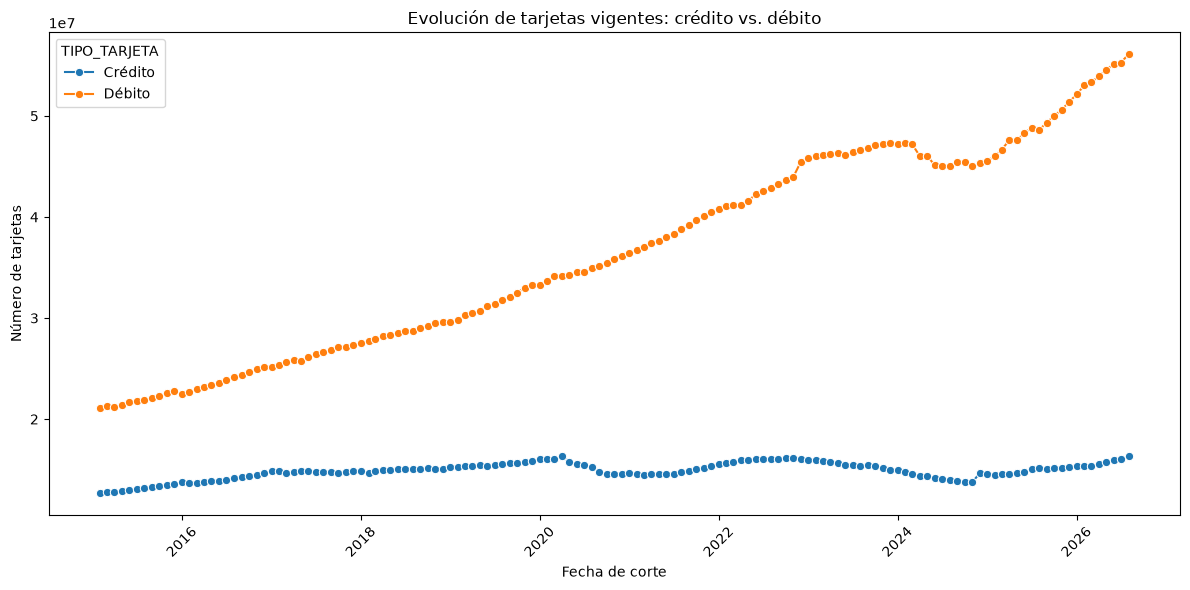

In [267]:
evolucion_vigentes = evolucion_tarjetas[
    evolucion_tarjetas["ESTADO"] == "Vigentes"
]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=evolucion_vigentes,
    x="FECHACORTE",
    y="TOTAL_TARJETAS",
    hue="TIPO_TARJETA",
    marker="o"
)

plt.title("Evolución de tarjetas vigentes: crédito vs. débito")
plt.xlabel("Fecha de corte")
plt.ylabel("Número de tarjetas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.2 Evolución de las tarjetas de crédito según estado

Se analiza el comportamiento de las tarjetas de crédito según su estado: vigentes, canceladas y bloqueadas temporalmente. La comparación permite identificar las variaciones de cada estado durante el periodo analizado.

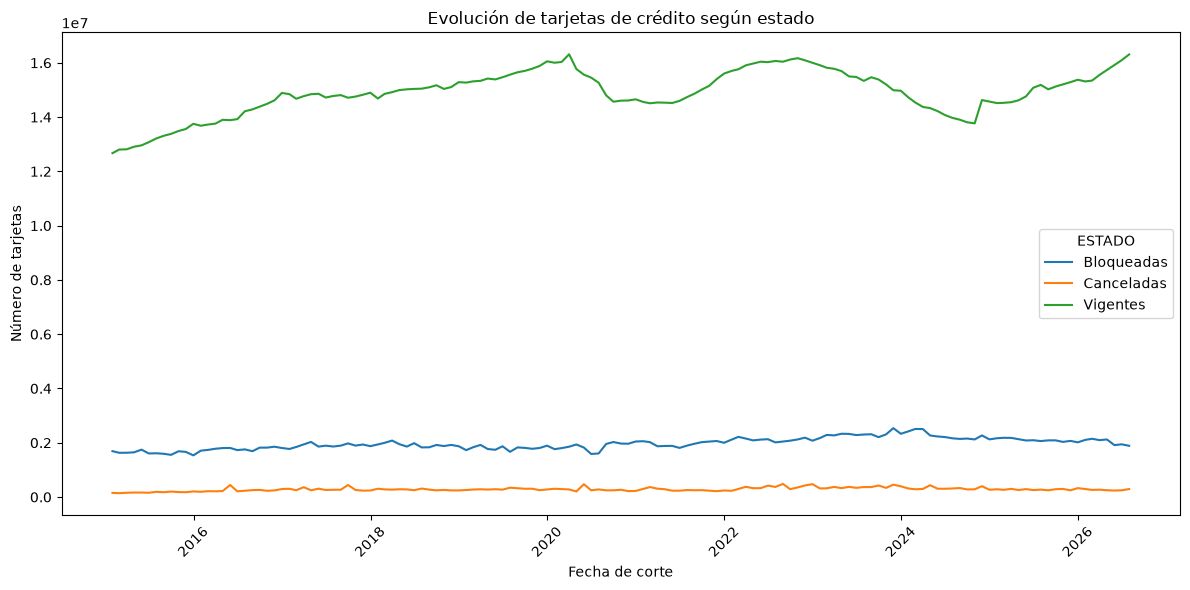

In [268]:
evolucion_credito = evolucion_tarjetas[
    evolucion_tarjetas["TIPO_TARJETA"] == "Crédito"
]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=evolucion_credito,
    x="FECHACORTE",
    y="TOTAL_TARJETAS",
    hue="ESTADO"
)

plt.title("Evolución de tarjetas de crédito según estado")
plt.xlabel("Fecha de corte")
plt.ylabel("Número de tarjetas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.3 Evolución de las tarjetas débito según estado

Se analiza el comportamiento de las tarjetas débito según su estado: vigentes, canceladas y bloqueadas temporalmente. La comparación permite identificar las variaciones de cada estado durante el periodo analizado y observar sus diferencias en cantidad a lo largo del tiempo.

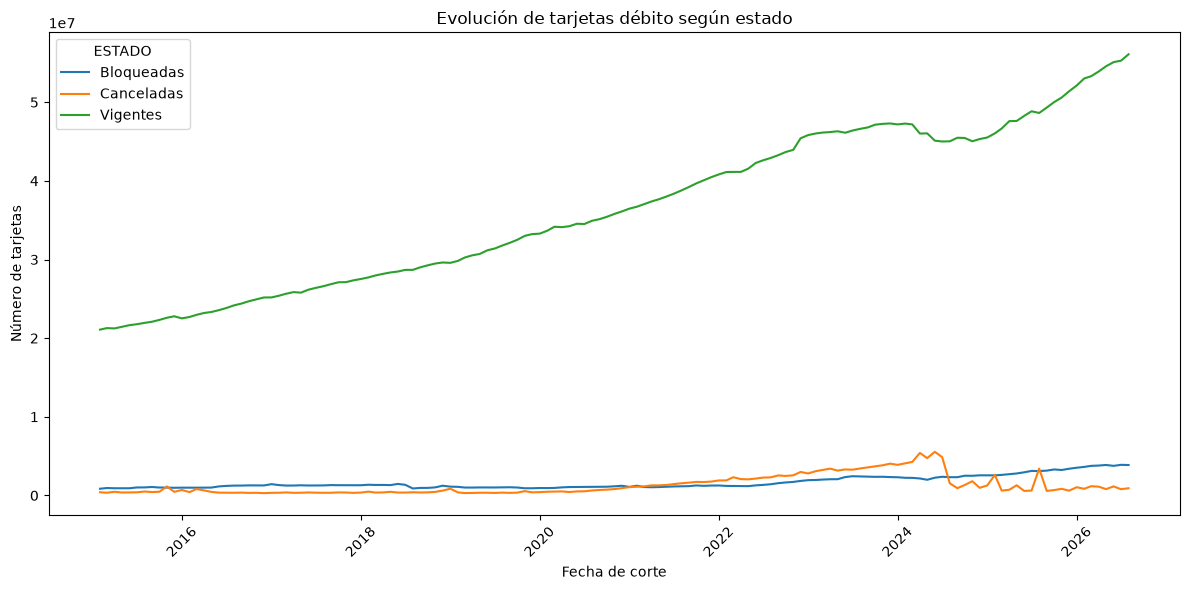

In [269]:
evolucion_debito = evolucion_tarjetas[
    evolucion_tarjetas["TIPO_TARJETA"] == "Débito"
]

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=evolucion_debito,
    x="FECHACORTE",
    y="TOTAL_TARJETAS",
    hue="ESTADO"
)

plt.title("Evolución de tarjetas débito según estado")
plt.xlabel("Fecha de corte")
plt.ylabel("Número de tarjetas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.4 Comparación temporal de los indicadores

Se comparan los principales indicadores de tarjetas de crédito y débito a través del periodo analizado. Esta comparación permite identificar diferencias en sus magnitudes y observar los cambios registrados según el tipo de tarjeta y su estado.

El análisis complementa las gráficas anteriores y facilita una visión conjunta del comportamiento temporal de los indicadores seleccionados.

In [270]:
comparacion_estados = (
    evolucion_tarjetas
    .groupby(["TIPO_TARJETA", "ESTADO"])["TOTAL_TARJETAS"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

comparacion_estados

,TIPO_TARJETA,ESTADO,mean,min,max
0,Crédito,Bloqueadas,1.969209e+06,1534708.0,2537390.0
1,Crédito,Canceladas,2.840396e+05,142090.0,483141.0
2,Crédito,Vigentes,1.490506e+07,12671012.0,16314232.0
3,Débito,Bloqueadas,1.653429e+06,852124.0,3890507.0
4,Débito,Canceladas,1.281728e+06,287411.0,5545699.0
5,Débito,Vigentes,3.645943e+07,21082367.0,56096483.0


Los resultados muestran que las tarjetas vigentes presentan los valores promedio más altos tanto para crédito como para débito. En ambos tipos de tarjeta, los registros bloqueados y cancelados presentan promedios considerablemente menores.

Además, el promedio de tarjetas débito vigentes es superior al de tarjetas crédito vigentes, manteniendo el mismo comportamiento observado en el análisis temporal anterior.

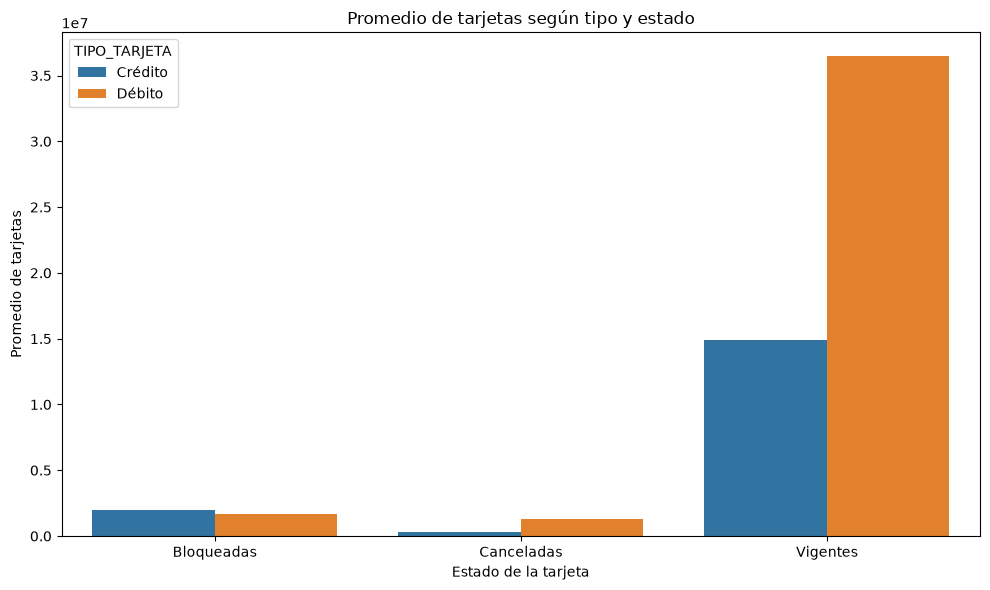

In [271]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparacion_estados,
    x="ESTADO",
    y="mean",
    hue="TIPO_TARJETA"
)

plt.title("Promedio de tarjetas según tipo y estado")
plt.xlabel("Estado de la tarjeta")
plt.ylabel("Promedio de tarjetas")
plt.tight_layout()
plt.show()

## 7. Análisis univariado

El análisis univariado permite estudiar la distribución y comportamiento de las principales variables seleccionadas del conjunto de datos. Se utilizan histogramas y diagramas de caja para identificar la distribución de los valores, su dispersión y posibles valores extremos.

In [272]:
df_tarjetas[[
    "TIPO_TARJETA",
    "ESTADO",
    "TOTAL_TARJETAS"
]].describe()

,TOTAL_TARJETAS
count,3.098900e+04
mean,2.536659e+05
std,1.044208e+06
min,1.000000e+00
25%,1.551000e+03
50%,1.321600e+04
75%,1.022620e+05
max,2.145069e+07



### 7.1 Distribución del número total de tarjetas

Se analiza la distribución del número total de tarjetas mediante un histograma. Debido a la amplitud de los valores observados, se utiliza una escala logarítmica en el eje horizontal para facilitar la visualización de la distribución.

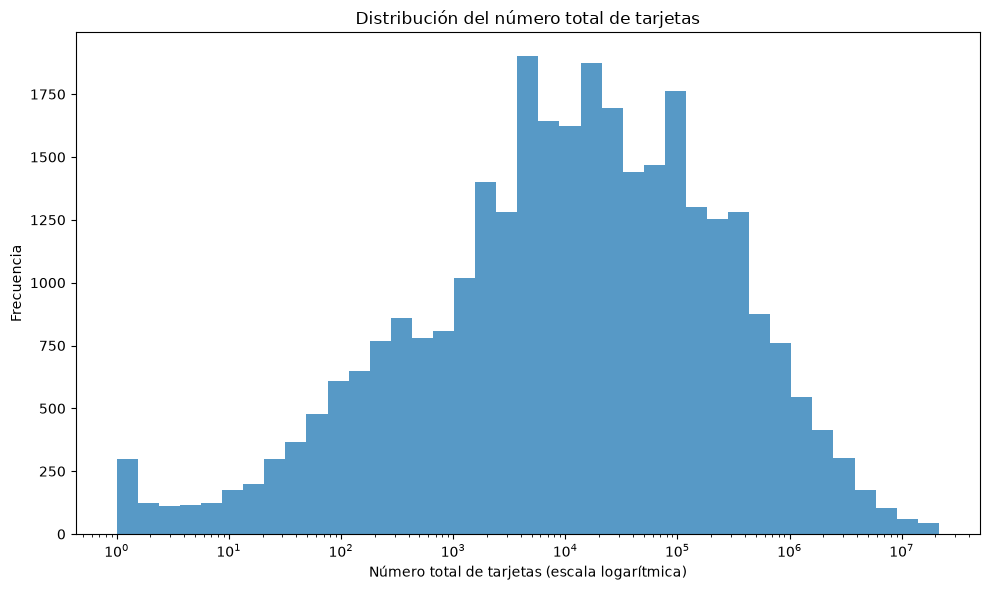

In [273]:
bins_log = np.logspace(
    np.log10(df_tarjetas["TOTAL_TARJETAS"].min()),
    np.log10(df_tarjetas["TOTAL_TARJETAS"].max()),
    40
)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_tarjetas,
    x="TOTAL_TARJETAS",
    bins=bins_log
)

plt.xscale("log")
plt.title("Distribución del número total de tarjetas")
plt.xlabel("Número total de tarjetas (escala logarítmica)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

### 7.2 Distribución y valores extremos del número total de tarjetas

Se utiliza un diagrama de caja para analizar la distribución del número total de tarjetas e identificar la dispersión de los valores y la posible presencia de valores extremos. Se mantiene la escala logarítmica para facilitar la visualización debido a la amplitud de los datos.

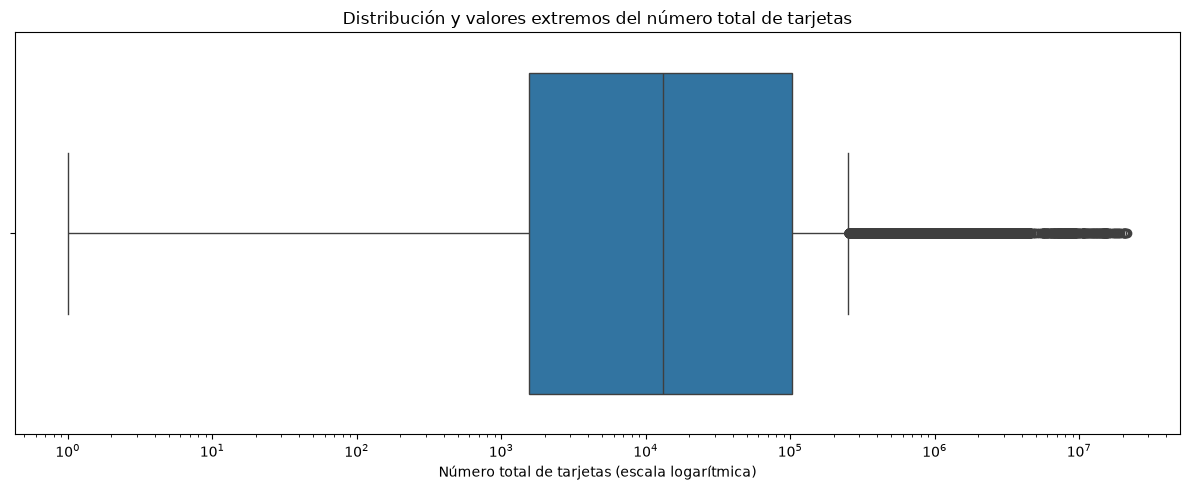

In [274]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df_tarjetas,
    x="TOTAL_TARJETAS"
)

plt.xscale("log")
plt.title("Distribución y valores extremos del número total de tarjetas")
plt.xlabel("Número total de tarjetas (escala logarítmica)")
plt.tight_layout()
plt.show()

### 7.3 Distribución del número total de tarjetas por tipo

Se compara la distribución del número total de tarjetas entre crédito y débito mediante un histograma. La utilización de una escala logarítmica permite visualizar de manera más clara la distribución de los valores debido a las diferencias en sus magnitudes.

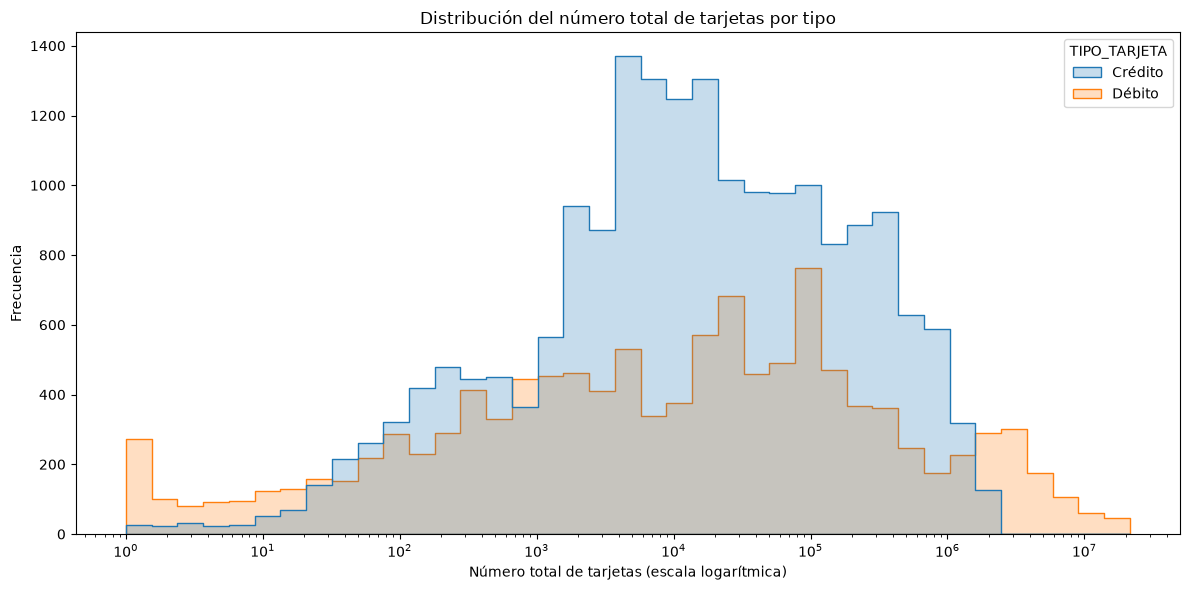

In [275]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df_tarjetas,
    x="TOTAL_TARJETAS",
    hue="TIPO_TARJETA",
    bins=bins_log,
    element="step",
    stat="count",
    common_bins=True
)

plt.xscale("log")
plt.title("Distribución del número total de tarjetas por tipo")
plt.xlabel("Número total de tarjetas (escala logarítmica)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

### 7.4 Distribución del número total de tarjetas por tipo

Se utiliza un diagrama de caja para comparar la distribución del número total de tarjetas entre crédito y débito. La escala logarítmica en el eje vertical facilita la comparación de los valores y permite observar su dispersión y posibles valores extremos.

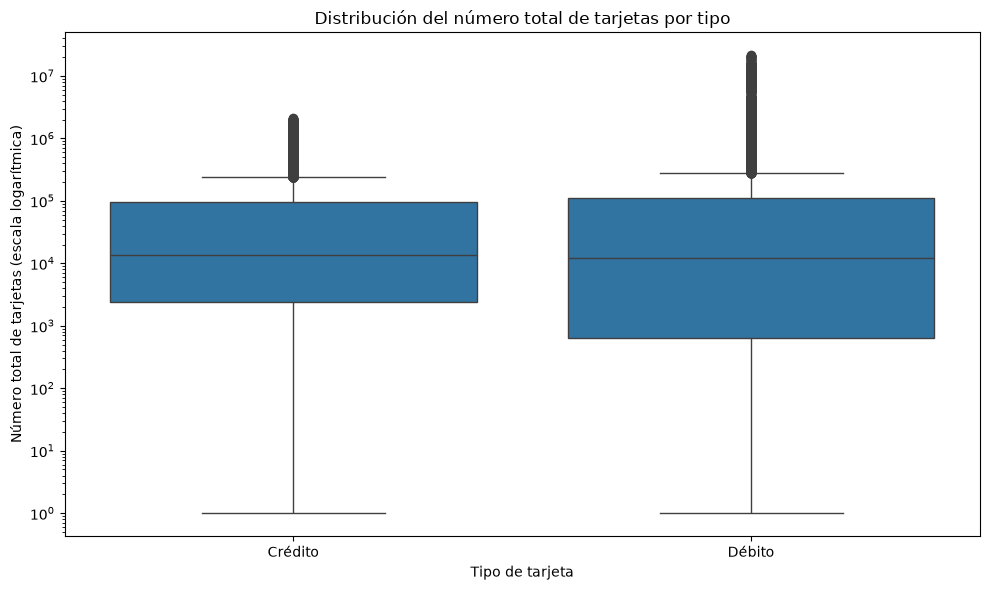

In [276]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_tarjetas,
    x="TIPO_TARJETA",
    y="TOTAL_TARJETAS"
)

plt.yscale("log")
plt.title("Distribución del número total de tarjetas por tipo")
plt.xlabel("Tipo de tarjeta")
plt.ylabel("Número total de tarjetas (escala logarítmica)")
plt.tight_layout()
plt.show()

## 8. Análisis bivariado

El análisis bivariado permite estudiar las relaciones entre los principales indicadores de tarjetas de crédito y débito mediante tablas y correlaciones.

### 8.1 Tabla comparativa de indicadores

Se organizan los indicadores por fecha, tipo de tarjeta y estado para facilitar su comparación durante el periodo analizado.

In [277]:
tabla_bivariada = (
    evolucion_tarjetas
    .pivot(
        index="FECHACORTE",
        columns=["TIPO_TARJETA", "ESTADO"],
        values="TOTAL_TARJETAS"
    )
)

tabla_bivariada

TIPO_TARJETA    Crédito                            Débito             \
ESTADO       Bloqueadas Canceladas    Vigentes Bloqueadas Canceladas   
FECHACORTE                                                             
2015-01-31    1690457.0   152392.0  12671012.0   852124.0   404009.0   
2015-02-28    1628937.0   142090.0  12803754.0   939690.0   344246.0   
2015-03-31    1631639.0   157306.0  12812204.0   912655.0   462970.0   
2015-04-30    1646322.0   164954.0  12907269.0   908328.0   371477.0   
2015-05-31    1746013.0   165058.0  12958351.0   911033.0   377510.0   
...                 ...        ...         ...        ...        ...   
2026-03-31    2095336.0   270040.0  15556546.0  3799098.0  1112530.0   
2026-04-30    2121432.0   250567.0  15734189.0  3870796.0   802364.0   
2026-05-31    1912100.0   238699.0  15918292.0  3760281.0  1146429.0   
2026-06-30    1942364.0   248340.0  16095267.0  3890507.0   792730.0   
2026-07-31    1887819.0   292597.0  16308520.0  3865157.0   913182.0   

TIPO_TARJETA              
ESTADO          Vigentes  
FECHACORTE                
2015-01-31    21082367.0  
2015-02-28    21277198.0  
2015-03-31    21235436.0  
2015-04-30    21440726.0  
2015-05-31    21650803.0  
...                  ...  
2026-03-31    53905414.0  
2026-04-30    54569441.0  
2026-05-31    55099032.0  
2026-06-30    55282806.0  
2026-07-31    56096483.0  

[139 rows x 6 columns]

### 8.2 Matriz de correlación

Se calcula la correlación entre los indicadores seleccionados para identificar posibles relaciones entre ellos.

In [278]:
correlacion = tabla_bivariada.corr()

correlacion

TIPO_TARJETA               Crédito                          Débito             \
ESTADO                  Bloqueadas Canceladas  Vigentes Bloqueadas Canceladas   
TIPO_TARJETA ESTADO                                                             
Crédito      Bloqueadas   1.000000   0.546020  0.353370   0.578862   0.762702   
             Canceladas   0.546020   1.000000  0.508478   0.227856   0.478775   
             Vigentes     0.353370   0.508478  1.000000   0.230942   0.196020   
Débito       Bloqueadas   0.578862   0.227856  0.230942   1.000000   0.346329   
             Canceladas   0.762702   0.478775  0.196020   0.346329   1.000000   
             Vigentes     0.766594   0.445038  0.514722   0.827621   0.596489   

TIPO_TARJETA                       
ESTADO                   Vigentes  
TIPO_TARJETA ESTADO                
Crédito      Bloqueadas  0.766594  
             Canceladas  0.445038  
             Vigentes    0.514722  
Débito       Bloqueadas  0.827621  
             Canceladas  0.596489  
             Vigentes    1.000000

### 8.3 Visualización de la correlación

La matriz de correlación se representa mediante un mapa de calor para facilitar la interpretación de las relaciones entre los indicadores.

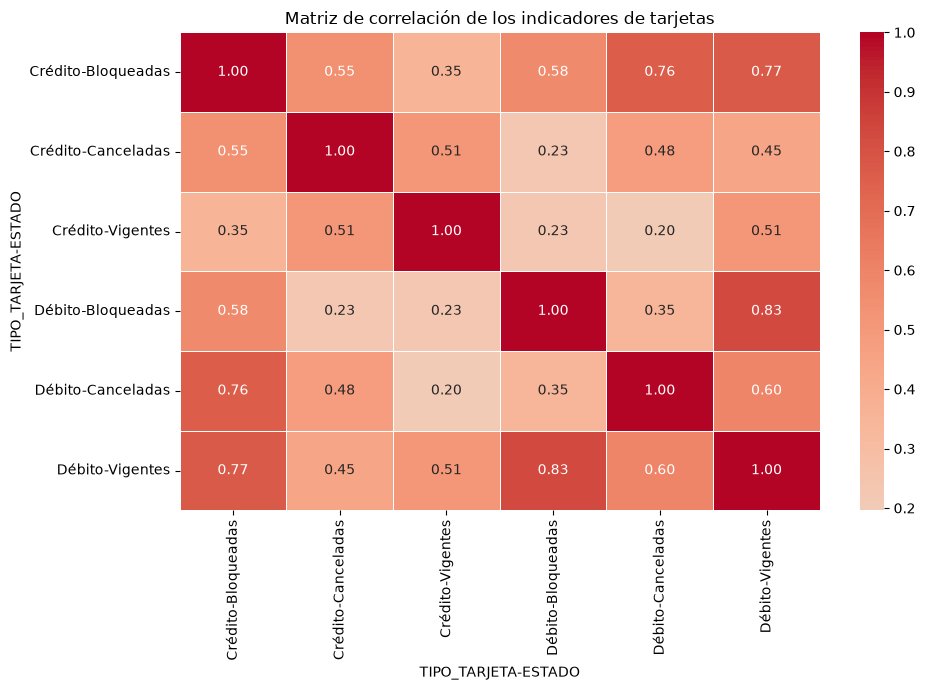

In [279]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matriz de correlación de los indicadores de tarjetas")
plt.tight_layout()
plt.show()

### 8.4 Relación entre tarjetas débito bloqueadas y vigentes

Se analiza la relación entre el número de tarjetas débito bloqueadas y el número de tarjetas débito vigentes mediante un gráfico de dispersión.

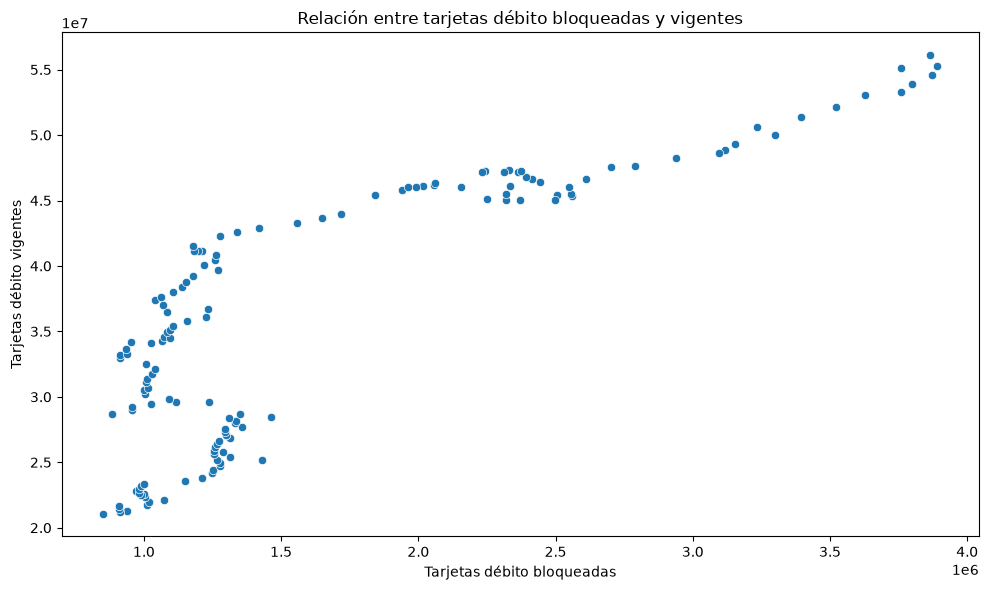

In [280]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=tabla_bivariada,
    x=("Débito", "Bloqueadas"),
    y=("Débito", "Vigentes")
)

plt.title("Relación entre tarjetas débito bloqueadas y vigentes")
plt.xlabel("Tarjetas débito bloqueadas")
plt.ylabel("Tarjetas débito vigentes")
plt.tight_layout()
plt.show()

### 8.5 Relación entre tarjetas de crédito bloqueadas y débito canceladas

Se analiza la relación entre las tarjetas de crédito bloqueadas y las tarjetas débito canceladas mediante un gráfico de dispersión.

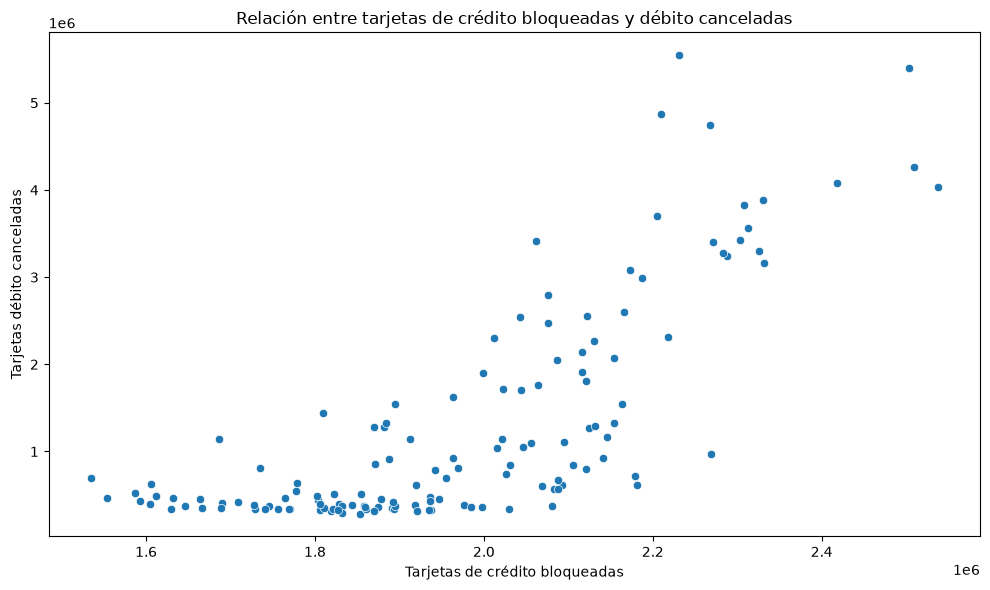

In [281]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=tabla_bivariada,
    x=("Crédito", "Bloqueadas"),
    y=("Débito", "Canceladas")
)

plt.title("Relación entre tarjetas de crédito bloqueadas y débito canceladas")
plt.xlabel("Tarjetas de crédito bloqueadas")
plt.ylabel("Tarjetas débito canceladas")
plt.tight_layout()
plt.show()

## 9. Análisis de agregaciones y entidades

En esta sección se utilizan agrupaciones para resumir los principales indicadores según el tipo de tarjeta, estado y entidad. Esto permite comparar los valores obtenidos y observar diferencias entre los grupos analizados.

### 9.1 Resumen estadístico por tipo y estado

Se resumen los valores del número total de tarjetas según el tipo de tarjeta y su estado, utilizando medidas de tendencia central y de dispersión como el promedio, la mediana, el mínimo y el máximo.

In [282]:
resumen_tipo_estado = (
    df_tarjetas
    .groupby(["TIPO_TARJETA", "ESTADO"])["TOTAL_TARJETAS"]
    .agg(
        promedio="mean",
        mediana="median",
        minimo="min",
        maximo="max"
    )
    .reset_index()
)

resumen_tipo_estado

,TIPO_TARJETA,ESTADO,promedio,mediana,minimo,maximo
0,Crédito,Bloqueadas,4.360683e+04,18591.0,1.0,479739.0
1,Crédito,Canceladas,6.122113e+03,2564.0,1.0,245695.0
2,Crédito,Vigentes,3.186409e+05,172576.0,1.0,2087560.0
3,Débito,Bloqueadas,6.956013e+04,2041.5,1.0,2868485.0
4,Débito,Canceladas,4.287850e+04,1833.0,1.0,4793325.0
5,Débito,Vigentes,1.178024e+06,130583.0,1.0,21450693.0


### 9.2 Comparación de entidades

Se analizan las entidades que presentan tarjetas vigentes, agrupándolas por nombre y tipo de tarjeta. Se calculan el promedio, la mediana y el valor máximo para identificar las diferencias entre las entidades.

In [283]:
resumen_entidades = (
    df_tarjetas[df_tarjetas["ESTADO"] == "Vigentes"]
    .groupby(["NOMBREENTIDAD", "TIPO_TARJETA"])["TOTAL_TARJETAS"]
    .agg(
        promedio="mean",
        mediana="median",
        maximo="max"
    )
    .reset_index()
    .sort_values("promedio", ascending=False)
)

resumen_entidades.head(10)

,NOMBREENTIDAD,TIPO_TARJETA,promedio,mediana,maximo
43,BANCOLOMBIA S.A.,Débito,1.190927e+07,10937434.0,21450693.0
16,BANCO DAVIVIENDA S.A.,Débito,5.987655e+06,5945580.0,9546731.0
6,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S.A. ...,Débito,3.743210e+06,3994367.0,4371542.0
4,BANCO AGRARIO DE COLOMBIA S.A.,Débito,2.646466e+06,2426558.0,4613715.0
18,BANCO DE BOGOTA S. A.,Débito,2.555362e+06,2481813.0,2979271.0
8,BANCO CAJA SOCIAL S.A.,Débito,2.440798e+06,2221800.0,3821010.0
10,BANCO COMERCIAL AV VILLAS S.A.,Débito,2.199929e+06,2282505.0,3068951.0
70,NU O NU FINANCIERA,Débito,1.815705e+06,1926921.0,3426336.0
69,NU O NU FINANCIERA,Crédito,1.349108e+06,1274279.0,2087560.0
76,TUYA S.A C.F,Crédito,1.109893e+06,1146907.0,1964880.0


### 9.3 Principales entidades por tipo de tarjeta

Se identifican las cinco entidades con mayor promedio de tarjetas vigentes para cada tipo de tarjeta. Esto permite comparar las entidades con mayores valores promedio dentro del periodo analizado.

In [284]:
top_entidades_tipo = (
    df_tarjetas[
        df_tarjetas["ESTADO"] == "Vigentes"
    ]
    .groupby(["TIPO_TARJETA", "NOMBREENTIDAD"])["TOTAL_TARJETAS"]
    .mean()
    .reset_index(name="PROMEDIO_TARJETAS")
)

top_entidades_tipo = (
    top_entidades_tipo
    .sort_values(
        ["TIPO_TARJETA", "PROMEDIO_TARJETAS"],
        ascending=[True, False]
    )
    .groupby("TIPO_TARJETA")
    .head(5)
)

top_entidades_tipo

,TIPO_TARJETA,NOMBREENTIDAD,PROMEDIO_TARJETAS
28,Crédito,NU O NU FINANCIERA,1.349108e+06
32,Crédito,TUYA S.A C.F,1.109893e+06
9,Crédito,BANCO FALABELLA S.A.,8.646488e+05
18,Crédito,BANCOLOMBIA S.A.,7.513849e+05
30,Crédito,SCOTIABANK COLPATRIA S.A.,5.836838e+05
57,Débito,BANCOLOMBIA S.A.,1.190927e+07
42,Débito,BANCO DAVIVIENDA S.A.,5.987655e+06
37,Débito,BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S.A. ...,3.743210e+06
36,Débito,BANCO AGRARIO DE COLOMBIA S.A.,2.646466e+06
43,Débito,BANCO DE BOGOTA S. A.,2.555362e+06


### 9.4 Visualización de las principales entidades

Se representa gráficamente el promedio de tarjetas vigentes de las cinco principales entidades para cada tipo de tarjeta, facilitando la comparación entre crédito y débito.

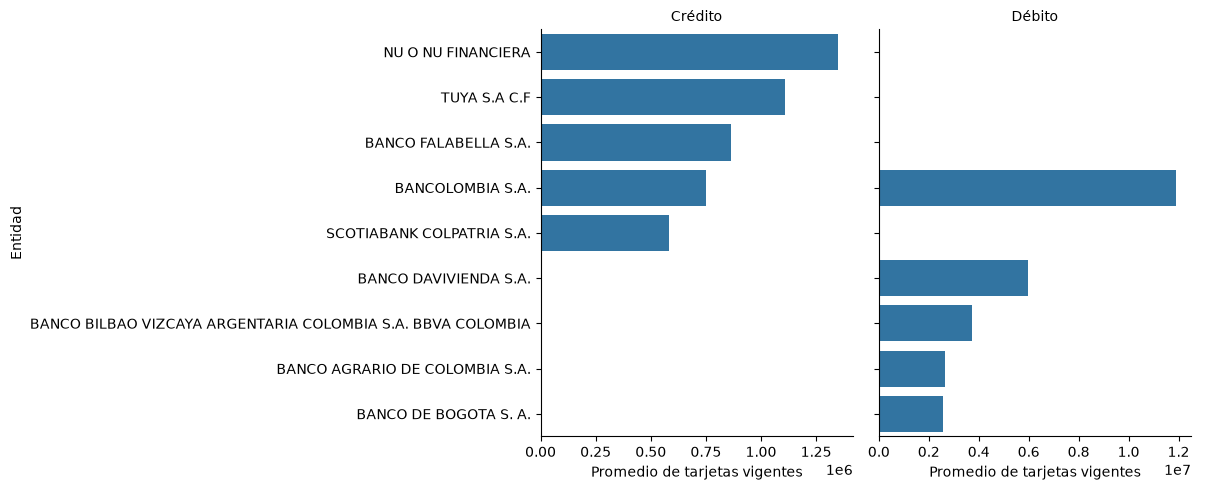

In [285]:
grafico_entidades = sns.catplot(
    data=top_entidades_tipo,
    x="PROMEDIO_TARJETAS",
    y="NOMBREENTIDAD",
    col="TIPO_TARJETA",
    kind="bar",
    sharex=False,
    height=5,
    aspect=1.2
)

grafico_entidades.set_axis_labels(
    "Promedio de tarjetas vigentes",
    "Entidad"
)

grafico_entidades.set_titles("{col_name}")

plt.tight_layout()
plt.show()

## 10. Respuestas a las preguntas de investigación

### 10.1 ¿Cómo ha evolucionado el número de tarjetas de crédito y débito a lo largo del tiempo?

Las tarjetas débito vigentes presentan valores superiores a las tarjetas de crédito durante el periodo analizado. En general, las tarjetas débito muestran una tendencia de crecimiento, aunque se observan variaciones y disminuciones en algunos periodos. Las tarjetas de crédito presentan un comportamiento más estable, con variaciones a lo largo del periodo y recuperación hacia los últimos registros.

### 10.2 ¿Cuál es el comportamiento de las tarjetas de crédito y débito vigentes, canceladas y bloqueadas temporalmente?

En ambos tipos de tarjeta, las tarjetas vigentes presentan los valores más altos. Las tarjetas bloqueadas y canceladas presentan valores inferiores y muestran variaciones durante el periodo. Las tarjetas débito vigentes presentan además un crecimiento general más marcado que las tarjetas de crédito vigentes.

### 10.3 ¿Qué diferencias se presentan entre los valores asociados a personas naturales y personas jurídicas?

Los valores de personas naturales y jurídicas presentan diferencias según el tipo de indicador. En los indicadores seleccionados de tarjetas débito, las variables de personas naturales y jurídicas presentan valores iguales a cero, mientras que `TOTAL_TARJETAS` registra valores positivos. En los indicadores de crédito sí se presentan valores registrados para personas naturales y jurídicas.

Además, se comprobó que `TOTAL_TARJETAS` no puede reconstruirse de manera general mediante la suma de `PERSONA_NATURAL` y `PERSONA_JURIDICA`. Por esta razón, `TOTAL_TARJETAS` se utilizó como variable principal para el análisis de la cantidad total de tarjetas.

### 10.4 ¿Qué diferencias se observan entre las tarjetas de crédito y débito al comparar sus valores promedio, medianos y extremos?

Las tarjetas débito presentan, en general, valores superiores a las tarjetas de crédito, especialmente en el indicador de tarjetas vigentes. También se observan diferencias entre el promedio y la mediana, lo que evidencia una distribución amplia de los valores y la presencia de valores extremos en algunos grupos.

Las mayores magnitudes corresponden a las tarjetas débito vigentes, mientras que los indicadores de crédito presentan valores menores, aunque también muestran variabilidad entre entidades y periodos.

### 10.5 ¿Qué relaciones pueden identificarse entre los principales indicadores mediante el análisis bivariado?

El análisis bivariado permite identificar relaciones positivas entre varios de los indicadores seleccionados. Las gráficas de dispersión muestran que las tarjetas débito bloqueadas y vigentes presentan un comportamiento conjunto, mientras que también se observa una relación entre las tarjetas de crédito bloqueadas y las tarjetas débito canceladas.

Las relaciones observadas corresponden a asociaciones entre variables y no permiten establecer relaciones de causalidad.

### 10.6 ¿Qué patrones se pueden identificar al comparar los indicadores entre entidades y periodos de tiempo?

Se observan diferencias entre las entidades en el promedio de tarjetas vigentes. Para las tarjetas de crédito, los mayores promedios de la selección realizada corresponden a entidades como NU O NU FINANCIERA, TUYA S.A. C.F., BANCO FALABELLA S.A., BANCOLOMBIA S.A. y SCOTIABANK COLPATRIA S.A. Para las tarjetas débito, se destacan BANCOLOMBIA S.A., BANCO DAVIVIENDA S.A., BANCO BILBAO VIZCAYA ARGENTARIA COLOMBIA S.A. - BBVA COLOMBIA, BANCO AGRARIO DE COLOMBIA S.A. y BANCO DE BOGOTA S.A.

Al comparar los periodos, las tarjetas débito vigentes mantienen una magnitud superior a las tarjetas de crédito vigentes, mientras que los indicadores de cancelación y bloqueo presentan variaciones a lo largo del tiempo.

## 11. Conclusiones

El análisis realizado permitió identificar el comportamiento de las tarjetas de crédito y débito durante el periodo comprendido entre 2015 y 2026. Los resultados muestran que las tarjetas débito vigentes presentan valores superiores a las tarjetas de crédito durante el periodo analizado y una tendencia general de crecimiento, aunque con variaciones en algunos años.

Las tarjetas vigentes representan el indicador con mayores valores tanto para crédito como para débito, mientras que las tarjetas canceladas y bloqueadas presentan magnitudes inferiores y comportamientos variables a lo largo del tiempo.

La revisión de las variables de personas naturales y jurídicas permitió identificar que su comportamiento depende del indicador analizado. En particular, para los indicadores de tarjetas débito seleccionados estas variables presentan valores iguales a cero, por lo que `TOTAL_TARJETAS` se utilizó como medida principal para representar la cantidad total de tarjetas.

El análisis estadístico mostró diferencias en los valores promedio, medianos y extremos entre los tipos de tarjeta, además de variaciones entre las entidades. Las agrupaciones realizadas permitieron identificar diferencias en los promedios de tarjetas vigentes entre las entidades analizadas.

Finalmente, el análisis bivariado permitió identificar relaciones entre algunos de los principales indicadores. Estas asociaciones muestran comportamientos conjuntos entre las variables, pero no permiten establecer relaciones de causalidad.

En conjunto, el análisis permitió responder las preguntas de investigación planteadas y evidenciar diferencias en el comportamiento de las tarjetas según su tipo, estado, entidad y periodo de tiempo.